In [1]:
# ==============================================================
# 🧑‍🩸 Donor Availability Prediction
# PART 1 - Data Loading & Initial Exploration (Fixed)
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
donors = pd.read_csv("synthetic_mumbai_donors_250k.csv")

print("Dataset Shape:", donors.shape)
print("Columns:", donors.columns.tolist())

# Remove duplicate rows
donors = donors.drop_duplicates()

# Convert date safely
donors['Last_Donation_Date'] = pd.to_datetime(
    donors['Last_Donation_Date'],
    dayfirst=True,
    errors='coerce'
)

# Check invalid dates
print("Invalid Dates:", donors['Last_Donation_Date'].isna().sum())

# Create Recency Feature
today = pd.Timestamp.today().normalize()

donors['Days_Since_Donation'] = (
    today - donors['Last_Donation_Date']
).dt.days

# Remove broken rows
donors = donors.dropna(subset=['Days_Since_Donation'])

# Remove future dates if any
donors = donors[donors['Days_Since_Donation'] >= 0]

# Convert datatype
donors['Days_Since_Donation'] = donors['Days_Since_Donation'].astype(int)

print("After Cleaning Shape:", donors.shape)

# Missing values check
print("\nMissing Values:")
print(donors.isnull().sum())

# Preview dataset
donors.head()

Dataset Shape: (250000, 13)
Columns: ['Donor_ID', 'Name', 'Age', 'Gender', 'Blood_Type', 'Location_Pincode', 'Last_Donation_Date', 'Total_Donations', 'Days_Since_Donation', 'Donor_Tier', 'Eligible', 'Availability_Probability', 'Will_Donate_Next_30_Days']
Invalid Dates: 0
After Cleaning Shape: (250000, 13)

Missing Values:
Donor_ID                    0
Name                        0
Age                         0
Gender                      0
Blood_Type                  0
Location_Pincode            0
Last_Donation_Date          0
Total_Donations             0
Days_Since_Donation         0
Donor_Tier                  0
Eligible                    0
Availability_Probability    0
Will_Donate_Next_30_Days    0
dtype: int64


,Donor_ID,Name,Age,Gender,Blood_Type,Location_Pincode,Last_Donation_Date,Total_Donations,Days_Since_Donation,Donor_Tier,Eligible,Availability_Probability,Will_Donate_Next_30_Days
0,MUM-D-100000,Diya Sachar,56,Male,AB+,400056,2024-08-24,8,603,Gold,1,0.66,1
1,MUM-D-100001,Osha Vohra,61,Male,B+,400004,2022-08-29,5,1329,Gold,1,0.34,1
2,MUM-D-100002,Faqid Naik,59,Male,O+,400050,2023-09-05,7,957,Gold,1,0.43,0
3,MUM-D-100003,Adweta Barad,56,Male,B+,400002,2022-07-19,4,1370,Silver,1,0.41,0
4,MUM-D-100004,Umang Baria,24,Male,B+,400026,2024-10-13,2,553,Silver,0,0.10,0


C:\Users\bisht\AppData\Local\Temp\ipykernel_19520\2036370657.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


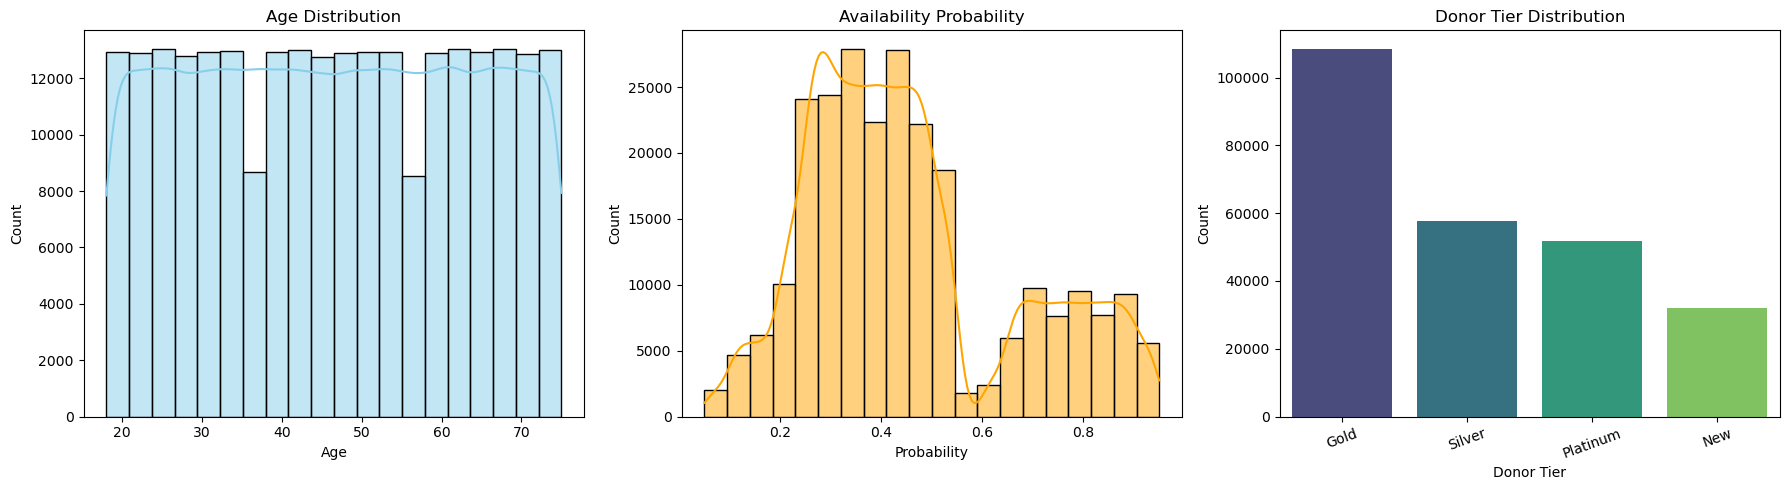

In [2]:
# ==============================================================
# 📊 PART 2 - Donor Insights Dashboard (Fixed)
# ==============================================================

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Age Distribution
sns.histplot(
    data=donors,
    x='Age',
    bins=20,
    color='skyblue',
    kde=True,
    ax=ax[0]
)
ax[0].set_title("Age Distribution")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Count")

# Availability Distribution
sns.histplot(
    data=donors,
    x='Availability_Probability',
    bins=20,
    color='orange',
    kde=True,
    ax=ax[1]
)
ax[1].set_title("Availability Probability")
ax[1].set_xlabel("Probability")
ax[1].set_ylabel("Count")

# Donor Tier Count
sns.countplot(
    data=donors,
    x='Donor_Tier',
    palette='viridis',
    order=donors['Donor_Tier'].value_counts().index,
    ax=ax[2]
)
ax[2].set_title("Donor Tier Distribution")
ax[2].set_xlabel("Donor Tier")
ax[2].set_ylabel("Count")

# Rotate labels if needed
ax[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [3]:
# ==============================================================
# 🧠 PART 3 - Feature Engineering (Fixed)
# ==============================================================

from sklearn.preprocessing import LabelEncoder

# Remove rows with required null values
donors = donors.dropna(
    subset=['Age', 'Gender', 'Donor_Tier', 'Days_Since_Donation', 'Availability_Probability']
)

# -------------------------
# Tier Mapping
# -------------------------
tier_mapping = {
    'Platinum': 3,
    'Gold': 2,
    'Silver': 1
}

donors['Tier_Score'] = donors['Donor_Tier'].map(tier_mapping)

# Fill unknown tiers if any
donors['Tier_Score'] = donors['Tier_Score'].fillna(0).astype(int)

# -------------------------
# Encode Gender
# -------------------------
le = LabelEncoder()
donors['Gender_Encoded'] = le.fit_transform(donors['Gender'].astype(str))

# -------------------------
# Clean Numeric Columns
# -------------------------
donors['Age'] = donors['Age'].astype(int)
donors['Days_Since_Donation'] = donors['Days_Since_Donation'].astype(int)

# Target column
donors['Availability_Probability'] = donors['Availability_Probability'].astype(float)

# -------------------------
# Feature Selection
# -------------------------
feature_cols = [
    'Age',
    'Gender_Encoded',
    'Tier_Score',
    'Days_Since_Donation'
]

X = donors[feature_cols]
y = donors['Availability_Probability']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

# Preview
print(X.head())

Feature Matrix Shape: (250000, 4)
Target Shape: (250000,)
   Age  Gender_Encoded  Tier_Score  Days_Since_Donation
0   56               1           2                  603
1   61               1           2                 1329
2   59               1           2                  957
3   56               1           1                 1370
4   24               1           1                  553


Training Model...


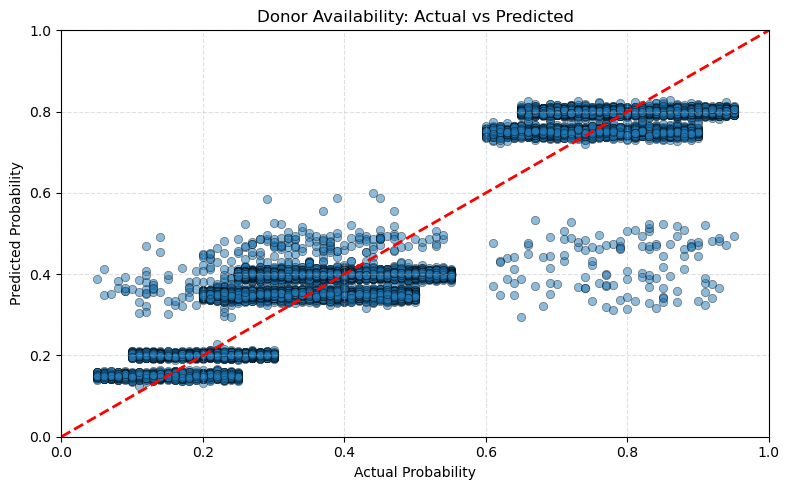

In [4]:
# ==============================================================
# 📊 PART 4 - Actual vs Predicted Visualization (Standalone Fixed)
# ==============================================================

# If model not trained yet, train here first

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Split Data
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -------------------------
# Train Model
# -------------------------
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

print("Training Model...")
xgb_model.fit(X_train, y_train)

# -------------------------
# Predict
# -------------------------
y_pred = xgb_model.predict(X_test)
y_pred = np.clip(y_pred, 0, 1)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5,
    edgecolors='black',
    linewidths=0.5
)

plt.plot([0, 1], [0, 1], 'r--', linewidth=2)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.xlabel("Actual Probability")
plt.ylabel("Predicted Probability")
plt.title("Donor Availability: Actual vs Predicted")

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [5]:
# ==============================================================
# 🚀 PART 5 - Train & Evaluate Model (Fixed)
# ==============================================================

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# -------------------------
# Train Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# -------------------------
# Model
# -------------------------
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# -------------------------
# Train
# -------------------------
print("Training Model...")

xgb_model.fit(
    X_train,
    y_train
)

# -------------------------
# Predict
# -------------------------
y_pred = xgb_model.predict(X_test)

# Probability bounds
y_pred = np.clip(y_pred, 0, 1)

# -------------------------
# Evaluation
# -------------------------
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R2 Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")

Training Model...
R2 Score : 0.8250
RMSE     : 0.0870
MAE      : 0.0738


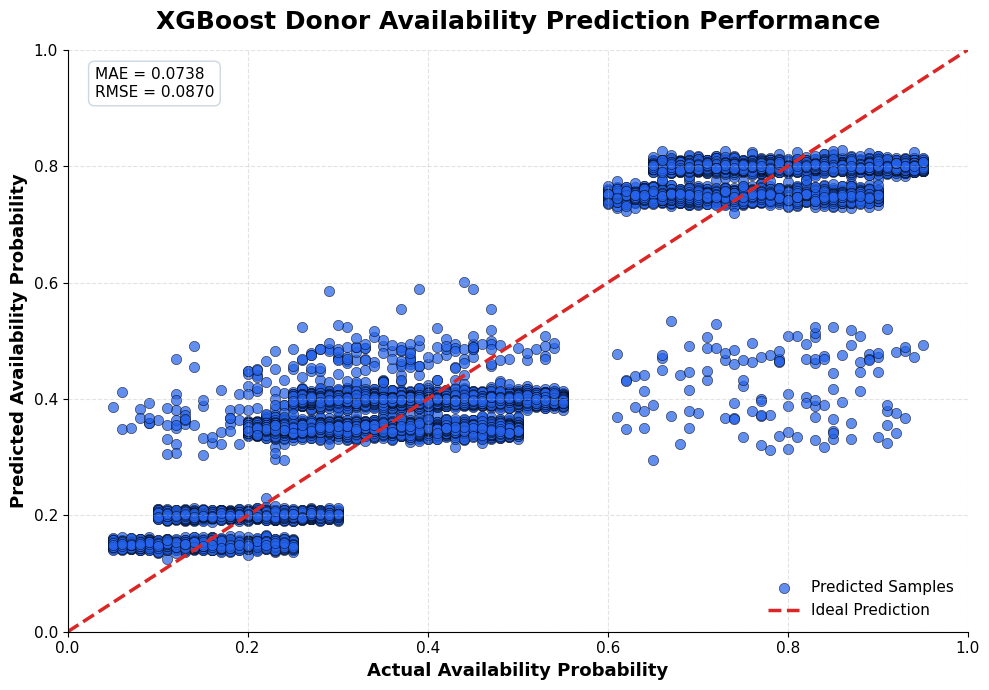

In [10]:
# ==============================================================
# 🏆 Premium Research Paper Graph
# XGBoost Actual vs Predicted Availability
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------
# Metrics
# ------------------------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# ------------------------------------------------
# Figure
# ------------------------------------------------
plt.figure(figsize=(10,7), facecolor='white')

# Scatter Plot
plt.scatter(
    y_test,
    y_pred,
    s=55,
    color='#2563eb',          # premium blue
    alpha=0.72,
    edgecolors='black',
    linewidths=0.45,
    label='Predicted Samples'
)

# Perfect Prediction Line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2.5,
    color='#dc2626',
    label='Ideal Prediction'
)

# ------------------------------------------------
# Metrics Box
# ------------------------------------------------
metrics = f"MAE = {mae:.4f}\nRMSE = {rmse:.4f}"

plt.text(
    0.03, 0.97,
    metrics,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor='white',
        edgecolor='#cbd5e1',
        alpha=0.95
    )
)

# ------------------------------------------------
# Labels
# ------------------------------------------------
plt.title(
    "XGBoost Donor Availability Prediction Performance",
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel("Actual Availability Probability", fontsize=13, fontweight='bold')
plt.ylabel("Predicted Availability Probability", fontsize=13, fontweight='bold')

plt.xlim(0,1)
plt.ylim(0,1)

# Grid
plt.grid(True, linestyle='--', alpha=0.35)

# Remove top/right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(frameon=False, fontsize=11, loc='lower right')

plt.tight_layout()

# ------------------------------------------------
# Save Publication Quality
# ------------------------------------------------
plt.savefig(
    "Fig_XGBoost_Availability_Performance.png",
    dpi=800,
    bbox_inches='tight'
)

plt.show()

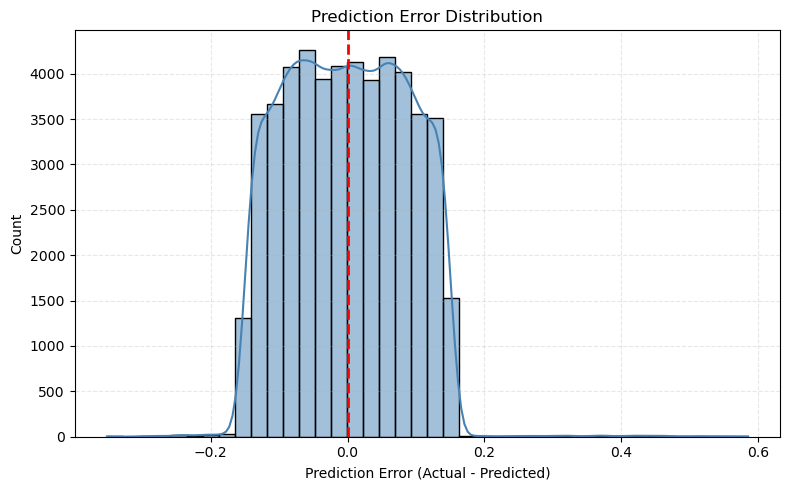

In [7]:
# ==============================================================
# 📉 Prediction Error Distribution (Fixed)
# ==============================================================

# Calculate Errors
errors = y_test - y_pred

plt.figure(figsize=(8, 5))

# Histogram
sns.histplot(
    errors,
    bins=40,
    kde=True,
    color='steelblue'
)

# Zero Error Reference Line
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2
)

# Labels & Title
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Prediction Error Distribution")

# Grid
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ==============================================================
# 💾 Save Model & Export Predictions (Fixed)
# ==============================================================

import os
import joblib

# Create folder
os.makedirs("ml_models", exist_ok=True)

# -------------------------
# Save Model Files
# -------------------------
joblib.dump(xgb_model, "ml_models/xgb_donor_model.pkl")
joblib.dump(le, "ml_models/gender_encoder.pkl")
joblib.dump(feature_cols, "ml_models/donor_feature_order.pkl")

# Optional metadata
joblib.dump(
    {
        "model_type": "XGBRegressor",
        "features": feature_cols
    },
    "ml_models/model_metadata.pkl"
)

# -------------------------
# Predict Full Dataset
# -------------------------
donors['Predicted_Availability'] = np.clip(
    xgb_model.predict(X),
    0,
    1
).round(4)

# -------------------------
# Save CSV
# -------------------------
donors.to_csv(
    "donors_with_predicted_availability.csv",
    index=False
)

print("✅ Model and artifacts saved successfully.")
print("📁 Folder: ml_models/")
print("📄 CSV: donors_with_predicted_availability.csv")

✅ Model and artifacts saved successfully.
📁 Folder: ml_models/
📄 CSV: donors_with_predicted_availability.csv
